In [67]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

In [68]:
old_files = ['MTR_SSA.dat']

path = 'dados-brutos/'
df = pd.read_csv(path + 'SSA_metar_2019-21_bruto.csv', sep=';')

path = 'old-databases/'
old_df = pd.read_csv(path + old_files[0], sep=',')
old_df.index = pd.to_datetime(old_df[['year', 'month', 'day', 'hour']])

In [69]:
df = df[['valid', 'tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'p01i', 'mslp']]

In [70]:
df['date'] = pd.to_datetime(df['valid']).dt.tz_localize('UTC').dt.tz_convert('America/Bahia')
df.index = df['date']

df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['hour'] = df.index.hour

In [71]:
#convert farenheit to celsius
df['T'] = (df['tmpf']-32)*(5/9)
df['Td'] = (df['dwpf']-32)*(5/9)
df['ur'] = df['relh']
df['WD'] = df['drct']
#convert knots do m/s
df['WS'] = df['sknt']*0.514444444
#convert inches to mm
df['precip'] = df['p01i']*25.4
df['pressure'] = df['mslp']
df['u'] = -df['WS']*np.sin(df['WD'])
df['v'] = -df['WS']*np.cos(df['WD'])

In [72]:
df = df[['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'WD', 'WS', 'u', 'v', 'precip', 'pressure']]

In [75]:
dft = pd.merge_ordered(old_df, df)
dft.index = pd.to_datetime(dft[['year', 'month', 'day', 'hour']])

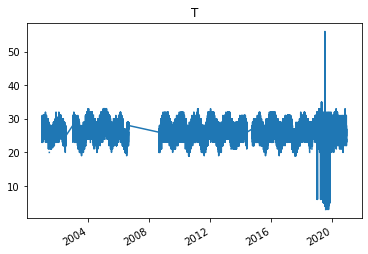

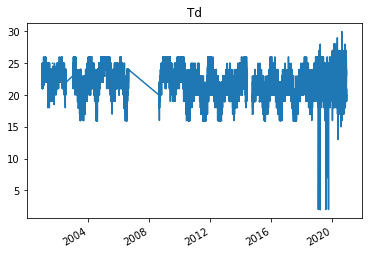

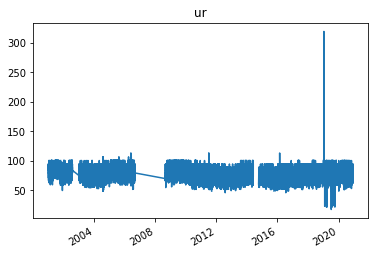

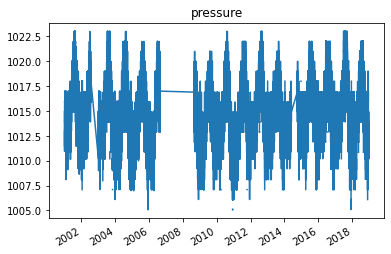

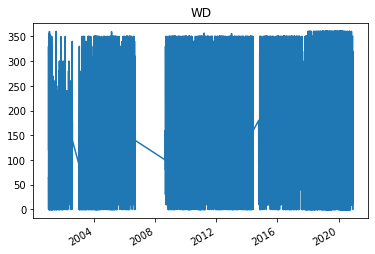

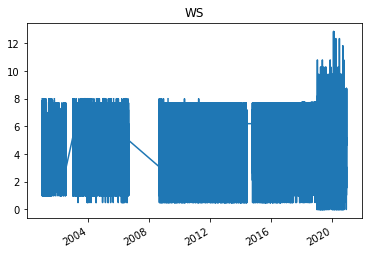

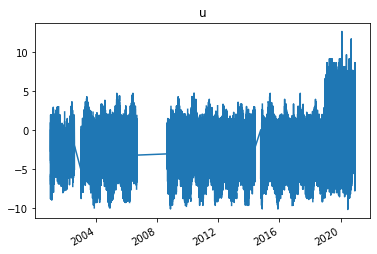

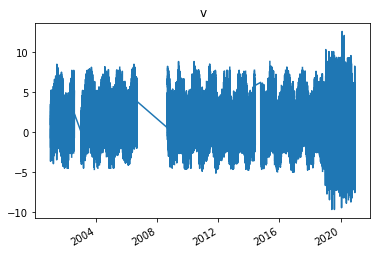

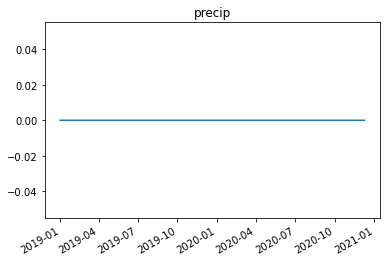

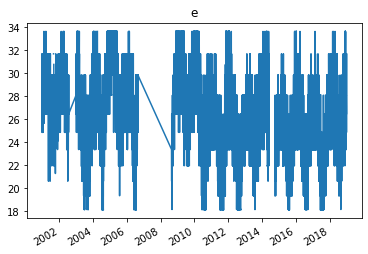

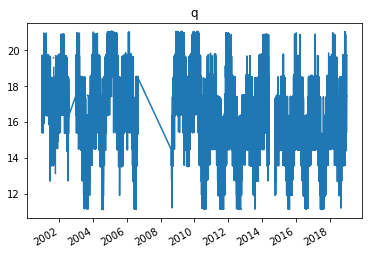

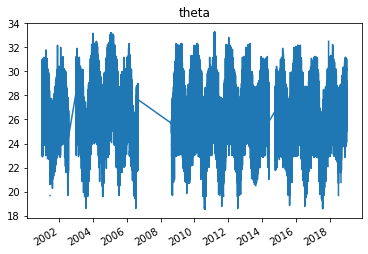

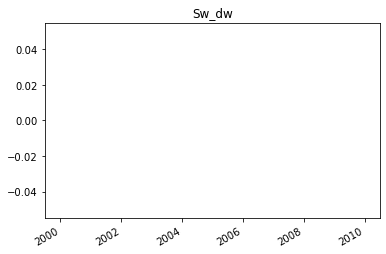

In [78]:
for col in dft.columns:
    if col not in ['year', 'month', 'day', 'hour']:
        dft[col].plot()
        plt.title(col)
        plt.show()
        plt.close()

In [80]:
dft.to_csv('new-databases/SSA_metar_completo.dat', sep=';', index=False, na_rep='NaN')